# Étape 2 — Prétraitement et Exploration des Données
### Dataset : all_youtube_comments.csv

## Cellule 1 — Imports

In [6]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
import emoji

print('✅ Imports OK')

✅ Imports OK


## Cellule 2 — Charger les données

In [7]:
df = pd.read_csv('../data/raw/all_domains_transcriptions.csv', encoding='utf-8-sig')

print(f'Nombre de textes : {len(df)}')
print(f'\nColonnes : {df.columns.tolist()}')
print(f'\nRépartition par catégorie :')
print(df['category'].value_counts())

Nombre de textes : 1136

Colonnes : ['id', 'text', 'source_platform', 'source_type', 'source_account', 'category', 'date', 'label']

Répartition par catégorie :
category
Politics/Société     336
Religion             199
Business/Économie    166
Sports/Fitness       163
Medical/Santé        152
Food/Cuisine         120
Name: count, dtype: int64


## Cellule 3 — Voir des exemples bruts

In [8]:
pd.set_option('display.max_colwidth', 200)
df[['text', 'category', 'source_type']].sample(10)

,text,category,source_type
654,الامه ارتكبناها دخل من خلالها من ثقوبها العدو المركزي اللي كتقول انت اليهود انا اقول ان العدو المركزي الان الصهيونيه الصهيونيه هناك يهود في العالم ضد الصهيونيه فوجب على اسمحي سي عبد العزيز اكمل نب...,Politics/Société,transcription
1033,اللي كيبقى حل من الحلول ولكن مازال خاص الخدمه في هذا الجانب هذا كيبان لي اننا مقتون من ناحيه الفرع را حتى في لونطريمون راكم شفتوا الطريقه كيفاش كيتشريو الدراري تيبانلك انه ضعاف ضعاف ضعاف ضعاف بزاف...,Sports/Fitness,transcription
414,لاميتود الثانيه طريقه الجيل الجديد من اللقاحات هذ الطريقه د اللقاح مريكله اشنو داروا شدوا الكود ديال الفيروس اللي هو لايرين اللي به الفيروس تيعاود يصنع راسه كيفما شرحنا قبيله شدوه وخداو منه ذاك ال...,Medical/Santé,transcription
292,مثلا ه الناس اللي عندهم القرون العصبي خص تعرف بان كاين واحد الفواكه وخضر خضره فواك مزيانين ولكن ما مزيان لهد الناس اللي فيها السكريد بزاف يعني فيها السكري بزاف ما مزيانا ليه كتبقى تنفخ ليهم المصرا...,Medical/Santé,transcription
916,هو الثبات في زمن في زمن الفتن مثله على مسامعنا الشيخ الشاب حفظه الله من مطلع سوره العنكبوت قول الله عز وجل الف لام ميم حسب الناس ان يتركوا ان يقولوا امنا وهم لا يفتنون ولقد فتنا الذين من قبلهم فلي...,Religion,transcription
915,مركب فحال هذا خاص الناس ديال المركب خصهم يقولوا اودي راه عند البرنامج على ثلاثه شهور وربع شهور ديما عامر والشباب تيتحركوا والحركه مثلا الجمعويه محركه والحركه مثلا ديال الجمعيات ديال الشباب اللي دي...,Religion,transcription
143,مخزون ذهبي كافي في هذ السنوات المقبله الى الخيار الاستراتيجي الصيني وديال البريكس هو اللي تغلب لهذا خصنا نكونوا مستعدين لكاع الاحتمالات ولهذا باك المغرب تنتمنى انها تراجع التدبير ديالها المخزون دي...,Business/Économie,transcription
312,مشكل في الحياه ديالك ستريسيتي عاود جات لك لاكريز هاهي مشات وليتي بخير عاود عاود رجعت لك يعني انت غتولي المريض يولي عارف فوقاش غتجيه لاكريز وكيشمها فهمت >> ديك الساعات ملي كيحس بها تيمشي عند الطبيب...,Medical/Santé,transcription
15,يعني في الشركات سالاري اولا موظفين عند الدوله كيخدموا النهار كامل بالاجره الاصلاح جا انه زاد وسع في الاعفاء الناس اللي كانوا كيتخلصوا 3000 درهم في العام طلع 40000 درهم في العام ما تلقاو تخلصوا حتى...,Business/Économie,transcription
750,حمايه المبلغين خصه يتقاد لانه فيه اجراءات ماخداماش بحال مثلا حمايه المبلغين اللي كيبلغوا باش يتحماو خصهم يبينوا ان ما عندهمش سوء النيه وكيفاش غادي يبينوا حسن النيه وهدشي اللي قالت الهيئه في التقري...,Politics/Société,transcription


## Cellule 4 — Détecter les problèmes

In [9]:
vides = df['text'].isna().sum()
print(f'Textes vides : {vides}')

courts = df[df['text'].str.split().str.len() <= 2]
print(f'Textes <= 2 mots : {len(courts)}')
print('\nExemples :')
print(courts['text'].head(10).tolist())

doublons = df.duplicated(subset=['text']).sum()
print(f'\nDoublons : {doublons}')

Textes vides : 0
Textes <= 2 mots : 0

Exemples :
[]

Doublons : 0


## Cellule 5 — Exemples de spam

In [10]:
# Cellule 5 — Exemples de spam
def has_repetition(text):
    if not isinstance(text, str):
        return False
    for i in range(len(text) - 4):
        if text[i] == text[i+1] == text[i+2] == text[i+3] == text[i+4]:
            return True
    return False

spam = df[df['text'].apply(has_repetition)]
print(f'Textes avec répétitions abusives : {len(spam)}')
print('\nExemples :')
print(spam['text'].head(10).tolist())

Textes avec répétitions abusives : 27

Exemples :
['المضافه سواء ديال الجمارك اولا ديال الداخليه وكاين انواع اخرى ديال الضرائب بحال الضريبه ديال التنبر تيك وبلا ما ندخل فيهم بزاف لان يدوخونا والقسم الثاني هما الضرائب اللي كتاخدهم الجماعات المحليه بحال الضريبه على النظافه الضريبه المهنيه اللي كتسمى باطونت ضريبه على شي اعلان علقتي في المحل وهكذا الاصلاحات اللي بداو في الضرائب بداو في العموم على هاد الثلاثه الكبار لي هما الضريبه على الشركات الضريبه على الدخل والضريبه على القيمه المضافه ونبداو بالاصلاح الاول اللي كان في 2023 كان على الضريبه على الشركات وهذه ضريبه كتخلص على ذاك الربح اللي حققت الشركه والضريبه على الشركات قبل من هذا الاصلاح كانت الناس اللي عندهم قل من 300000 درهم كربح اللي هي 30 مليون السنتيم كانوا كيخلصوا 10% والناس اللي عندهم ارباح ما بين 300000 ومليون ددرهم تيخلصوا 20% والناس اللي عندهم فوق مليون ددرهم د الارباح تيخلصوا 31% هذ القضيه تبدلت كامله في الاصلاح اللي داه واللي فيه انه', 'الناس اللي عندهم اقل من 300000 درهم كربح غادي يوليو يخلصوا 20% بدل 10 والناس اللي ما بين 30

## Cellule 6 — Fonction de nettoyage

In [11]:
import re
import emoji

AUDIO_PATTERNS = [
    r'\[?\s*موسيقى\s*\]?', r'\[?\s*ضحك\s*\]?', r'\[?\s*تصفيق\s*\]?',
    r'\[?\s*music\s*\]?', r'\[?\s*laugh(ter)?\s*\]?', r'\[?\s*applause\s*\]?'
]

CTA_PATTERNS = [
    r'ما\s*تنساوش', r'ما\s*تنساو?ش',
    r'اشترك', r'دير\s*لايك', r'ديرو\s*لايك', r'لايك',
    r'سبسكرايب', r'subscribe', r'sub', r'abonne', r'abonner',
    r'بارتاج', r'partage', r'comment', r'كومنطي'
]

SPONSOR_PATTERNS = [
    r'برعاية', r'هذا\s*الفيديو\s*برعاية', r'هاد\s*الفيديو\s*برعاية',
    r'إشهار', r'اشهار', r'sponsor', r'sponsored',
    r'paid partnership'
]

OUTRO_PATTERNS = [
    r'إلى\s*فيديو\s*قادم', r'الى\s*فيديو\s*قادم',
    r'نشوفكم\s*في\s*فيديو', r'نشوفوكم\s*في\s*فيديو',
    r'في\s*الفيديو\s*الجاي', r'الحلقة\s*الجاية'
]

def basic_clean_transcription(text):
    if not isinstance(text, str):
        return None

    text = text.strip()
    if not text:
        return None

    # URLs / hashtags / mentions
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)

    # Emojis
    text = emoji.replace_emoji(text, replace=' ')

    # garder arabe + latin + chiffres + ponctuation légère
    text = re.sub(r"[^\u0600-\u06FF\u0750-\u077Fa-zA-Z0-9\s،,.!?;:%'\"()\-\[\]]", ' ', text)

    # réduire répétitions de caractères
    text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)

    # réduire répétitions de blocs
    text = re.sub(r'(.{2,}?)\1{2,}', r'\1', text)

    # espaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text if text else None

def remove_noise_patterns(text):
    if not isinstance(text, str):
        return None

    patterns = AUDIO_PATTERNS + CTA_PATTERNS + SPONSOR_PATTERNS + OUTRO_PATTERNS
    for p in patterns:
        text = re.sub(p, ' ', text, flags=re.IGNORECASE)

    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else None

def clean_text(text):
    text = basic_clean_transcription(text)
    if text is None:
        return None

    text = remove_noise_patterns(text)
    if text is None:
        return None

    return text if len(text.strip()) > 0 else None

print('✅ Fonction clean_text définie pour les transcriptions')

✅ Fonction clean_text définie pour les transcriptions


## Cellule 7 — Appliquer le nettoyage de base

In [12]:
avant = len(df)
print(f'Avant nettoyage : {avant}')

df['text_clean'] = df['text'].apply(clean_text)

df = df.dropna(subset=['text_clean'])
df = df.drop_duplicates(subset=['text_clean'])

print(f'Après nettoyage léger : {len(df)}')
print(f'Supprimés             : {avant - len(df)}')

Avant nettoyage : 1136
Après nettoyage léger : 1136
Supprimés             : 0


## Cellule 8 — Vérifier avant/après nettoyage

In [13]:
pd.set_option('display.max_colwidth', 150)
df[['text', 'text_clean']].sample(15)

,text,text_clean
548,ماخصهاش تسقط لان في هذا الايكوسيستيم الكبير تتلعب واحد الدور محوري ديال التوا وازن ما بين عده اقطاب وهذاشي ال هضرنا على ان ايران تتسلح البوليزاريو...,ماخصهاش تسقط لان في هذا ا وسيستيم الكبير تتلعب واحد الدور محوري ديال التوا وازن ما بين عده اقطاب وهذاشي ال هضرنا على ان ايران تتسلح البوليزاريو ال...
1104,يربحو الماتش غير هو في الدقيقه 85 48 هذاك راه بينالتيفار ديال اجغلال انا جاني على بينالتي ماكنفهمش في التحكيم بزاف ولكن اخوتي انا بان ليا ذاك راه ...,يربحو الماتش غير هو في الدقيقه 85 48 هذاك راه بينالتيفار ديال اجغلال انا جاني على بينالتي ماكنفهمش في التحكيم بزاف ولكن اخوتي انا بان ليا ذاك راه ...
1045,السلام عليكم ورحمه الله تعالى وبركاته سمحو لينا غبرنا عليكم واحد الشويه كنت طايح اخوتي في الفراش السخانه الرواح كلشي تجمع عليا هاد السيمانه زايد و...,السلام عليكم ورحمه الله تعالى وبركاته سمحو لينا غبرنا عليكم واحد الشويه كنت طايح اخوتي في الفراش السخانه الرواح كلشي تجمع عليا هاد السيمانه زايد و...
814,اخرى باغا تجمد الصباح قالت لي قول لا القضيه وما فيها هو علاقه ابنائنا باللغه العربيه هل نجتهد في بيوتنا على ابنائنا لكي يعظموا اللغه العربيه بالخش...,اخرى باغا تجمد الصباح قالت لي قول لا القضيه وما فيها هو علاقه ابنائنا باللغه العربيه هل نجتهد في بيوتنا على ابنائنا لكي يعظموا اللغه العربيه بالخش...
589,عندهم مواهب عندهم قدرات ذهنيه فكريه ثقافيه الى اخره باغين غير يعيشوا بكرامه بداكشي اللي تيعرفوا يديروا بالحرفه اللي تيمتلكوها ولا بالمهارات اللي ط...,عندهم مواهب عندهم قدرات ذهنيه فكريه ثقافيه الى اخره باغين غير يعيشوا بكرامه بداكشي اللي تيعرفوا يديروا بالحرفه اللي تيمتلكوها ولا بالمهارات اللي ط...
935,نبقى الواحد متبع داكشي اللي هو باغي داكشي اللي هو شهيد يجد نفسه في النار ان كل الطرق التي تؤدي الى الجنه راه خاصني نقلب على داك الطريق اللي فيه ال...,نبقى الواحد متبع داكشي اللي هو باغي داكشي اللي هو شهيد يجد نفسه في النار ان كل الطرق التي تؤدي الى الجنه راه خاصني نقلب على داك الطريق اللي فيه ال...
495,1582 بدأ السلطان سياسة صحراوية من أجل قطع الطريق أمام العثمانيين الذين كانوا يريدون السيطرة على المنطقة خصوصا واحات توات و تيكورارين لأنها واحات غ...,1582 بدأ السلطان سياسة صحراوية من أجل قطع الطريق أمام العثمانيين الذين كانوا يريدون السيطرة على المنطقة خصوصا واحات توات و تيكورارين لأنها واحات غ...
596,بودكاستر في ميريكان ولا في فرنسا ولا في هولندا ولا يدير لي فيني ولا يدير شي حاجه فوغرافي الى اخره تيحتاج ديزابون مايبقاش ديما بيراطي وتيليشوروندير...,بودكاستر في ميريكان ولا في فرنسا ولا في هولندا ولا يدير لي فيني ولا يدير شي حاجه فوغرافي الى اخره تيحتاج ديزابون مايبقاش ديما بيراطي وتيليشوروندير...
755,طحتي في موقف اللي لقيتي راسك مجبر على انك دير عمليه فساد باش تاخذ غير حقك خليو لينا القصص ديالكم تحت في التعليق غادي يكونوا مهمين وغادي يقراوهم ال...,طحتي في موقف اللي لقيتي راسك مجبر على انك دير عمليه فساد باش تاخذ غير حقك خليو لينا القصص ديالكم تحت في التعليق غادي يكونوا مهمين وغادي يقراوهم ال...
152,خاص ديك الخنسه ديما تكون ره ملاقه مزيان فهمت لحد الان هشي ياك دا السؤال المهم ما معنى تحرير سعر صرف الدرهم عباد الله كيفاش التحرير تمال مربوط تطلق...,خاص ديك الخنسه ديما تكون ره ملاقه مزيان فهمت لحد الان هشي ياك دا السؤال المهم ما معنى تحرير سعر صرف الدرهم عباد الله كيفاش التحرير تمال مربوط تطلق...


## Cellule 9 — Filtrage avancé (vulgaires + FR/EN + inutiles)

In [14]:
# --- Ressources pour détection MSA / Darija / FR-EN ---
MSA_HINTS = {
    'يجب', 'ينبغي', 'يمكن', 'جميع', 'الأحزاب', 'السياسية', 'المواطنين',
    'المتظاهرين', 'السلميين', 'رجال', 'الأمن', 'السلطات', 'استقالة',
    'الصحافة', 'المستوى', 'الذي', 'التي', 'هذا', 'هذه', 'ذلك',
    'تلك', 'هناك', 'حيث', 'كما', 'لقد', 'تم', 'أثناء', 'منذ',
    'حول', 'ضمن', 'إلى', 'على', 'بعد', 'قبل', 'مع', 'بين'
}

DARIJA_HINTS = {
    'واش', 'علاش', 'حيت', 'حيتاش', 'ديال', 'عندي', 'عندو', 'عندها',
    'بزاف', 'هاد', 'هاذ', 'راه', 'ماشي', 'كاين', 'كين', 'مزيان',
    'دابا', 'غادي', 'عافاك', 'حنا', 'نتا', 'نتي', 'بصح', 'فين',
    'كيفاش', 'والو', 'شحال', 'عفاك', 'بلا'
}

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    return re.findall(r'[\u0600-\u06FFa-zA-Z0-9]+', text.lower())

def score_msa_vs_darija(text):
    words = tokenize_text(text)
    msa_score = sum(1 for w in words if w in MSA_HINTS)
    darija_score = sum(1 for w in words if w in DARIJA_HINTS)
    return msa_score, darija_score, len(words)

def is_msa_dominant(text):
    if not isinstance(text, str):
        return False

    words = tokenize_text(text)
    if len(words) < 5:
        return False

    msa_score, darija_score, total = score_msa_vs_darija(text)

    if msa_score >= 3 and darija_score == 0:
        return True

    msa_ratio = msa_score / max(total, 1)
    if msa_score >= 4 and msa_ratio >= 0.2 and darija_score == 0:
        return True

    return False

def is_fr_en_dominant(text):
    if not isinstance(text, str):
        return False

    if re.search(r'[\u0600-\u06FF]', text):
        return False

    words = tokenize_text(text)
    if len(words) < 5:
        return False

    darija_latin_markers = {
        'wach', '3lach', '7it', 'hit', 'bzf', 'bzaf', 'had', 'hada', 'hadi',
        'makayn', 'ma3ndich', 'machi', 'rah', 'safi', 'walou', 'daba',
        'ghadi', 'nta', 'nti', 'kifach', 'fin', 'mskin', 'meskin'
    }

    fr_en_markers = {
        'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
        'the', 'is', 'are', 'was', 'were', 'with', 'for', 'this', 'that',
        'and', 'merci', 'bonjour', 'salut', 'good', 'nice', 'great',
        'video', 'love', 'thanks', 'please', 'very', 'well', 'best', 'super'
    }

    fr_en_score = sum(1 for w in words if w in fr_en_markers)
    darija_latin_score = sum(1 for w in words if w in darija_latin_markers)

    if fr_en_score >= 3 and darija_latin_score == 0:
        return True

    if fr_en_score / max(len(words), 1) >= 0.5 and darija_latin_score == 0:
        return True

    return False

mots_interdits = [
    r'\b9awad\b', r'\b9lawi\b', r'\bzebi\b', r'\bzbi\b',
    r'\bt7wa\b', r'\bl7wa\b', r'\b9ahba\b', r'\b3ahra\b',
    r'\bmkhanez\b', r'\bmchayef\b',
    r'\bقود\b', r'\bزبي\b', r'\bقلاوي\b',
    r'\bلحوا\b', r'\bعاهرة\b', r'\bقحبة\b'
]

pattern_vulgaire = re.compile('|'.join(mots_interdits), re.IGNORECASE)

def contient_vulgaire(text):
    if not isinstance(text, str):
        return False
    return bool(pattern_vulgaire.search(text))

def is_only_numbers_or_punct(text):
    if not isinstance(text, str):
        return True
    return bool(re.fullmatch(r'[\W\d_ ]+', text))

def est_segment_parasite(text):
    if not isinstance(text, str):
        return True

    t = text.strip().lower()

    if is_only_numbers_or_punct(t):
        return True

    if len(t.split()) < 5:
        return True

    parasite_patterns = AUDIO_PATTERNS + CTA_PATTERNS + SPONSOR_PATTERNS + OUTRO_PATTERNS
    if any(re.search(p, t, flags=re.IGNORECASE) for p in parasite_patterns):
        return True

    return False

avant_avance = len(df)
print(f'Avant filtrage avancé : {avant_avance}')

df['is_vulgar'] = df['text_clean'].apply(contient_vulgaire)
df['is_fr_en_dominant'] = df['text_clean'].apply(is_fr_en_dominant)
df['is_msa_dominant'] = df['text_clean'].apply(is_msa_dominant)
df['is_parasite'] = df['text_clean'].apply(est_segment_parasite)

mask_vulgar = df['is_vulgar']
mask_fr_en = df['is_fr_en_dominant']
mask_msa = df['is_msa_dominant']
mask_parasite = df['is_parasite']

print(f'  Vulgaires       : {mask_vulgar.sum()}')
print(f'  FR/EN dominants : {mask_fr_en.sum()}')
print(f'  MSA dominants   : {mask_msa.sum()}')
print(f'  Parasites       : {mask_parasite.sum()}')

df_clean = df.loc[
    ~mask_vulgar &
    ~mask_fr_en &
    ~mask_msa &
    ~mask_parasite
].copy()

print(f'\nAprès filtrage avancé : {len(df_clean)}')
print(f'Total supprimés       : {avant_avance - len(df_clean)}')

Avant filtrage avancé : 1136
  Vulgaires       : 0
  FR/EN dominants : 0
  MSA dominants   : 60
  Parasites       : 0

Après filtrage avancé : 1076
Total supprimés       : 60


## Cellule 10 — Vérifier ce qui a été supprimé

In [15]:
print('=== Vulgaires supprimés ===')
print(df[mask_vulgar]['text_clean'].head(5).tolist())

print('\n=== FR/EN supprimés ===')
print(df[mask_fr_en]['text_clean'].head(5).tolist())

print('\n=== MSA dominants supprimés ===')
print(df[mask_msa]['text_clean'].head(5).tolist())

print('\n=== Segments parasites supprimés ===')
print(df[mask_parasite]['text_clean'].head(5).tolist())

=== Vulgaires supprimés ===
[]

=== FR/EN supprimés ===
[]

=== MSA dominants supprimés ===
['وفي نفس الوقت يعني كتجي هشيشه بزافها ما كتشرب ولا نقطه زيت ها انتما من بعد ما كنقسمها صراحه كتجي زوينه هذه الحلوه اذا وصلنا احبائي لنهايه الفيديو نتمنى يكون نال الاعجاب ديالكم طبعا اذا وصلتوا معيا لهذ المرحله من المشاهده فكنبغي نقول لكم شكرا على حسن المتابعه ما تنساونيش من لي ديالكم ايضا تعليقاتكم محفزه والى هنا تنقوللكم بسلامه Ah.', 'تعال لتفهم ما فهمته حول ما حدث بين المغرب والجزائر ( الجزء الأول) أجل أجل، أنا أيضا لدي نفس الملاحظة مر أكثر من عام قبل أن ننتج مقطع فيديو جديد لكننا عدنا وبقوة، سنقدم لكم سلسلة من الفيديوهات حول تاريخ المغرب والمنطقة المغاربية. وأنا على يقين تام أن هذه السلسلة ستنال إعجابكم وستلقى صدى كبيرا في الساحة الثقافية ولكن قبل أن ننطلق أريد توضيح نقطة مهمة حول المصادر التي اعتمدناها في إنتاج هذه السلسلة الغنية بالتفاصيل التاريخية إذ لم نعتمد على الروايات الشفهية وكتب الكتاب المبنية على مصالح سياسية وإنما استندنا على مصادر موثوقة، من قبيل كتب المؤرخين المشهود لهم بالمصداق

## Cellule 11 — Vérifier ce qui reste

In [16]:
print('=== Exemples gardés ===')
print(df_clean['text_clean'].sample(15).tolist())

print(f'\nRépartition finale :')
print(df_clean['category'].value_counts())

=== Exemples gardés ===
['واحد الفقره ان شاء الله سبحانه وتعالى ديال الاسئله بشرط ان تكون داخل الموضوع اي واحد طرح شي سؤال خارج الموضوع يرفض بارك الله فيكم ف شي سؤال ولا جوج شي تقريبا شي ثلاثه الاسئله ان شاء الله هو قال جوج انا زدت واحد بارك الله فيك السي الناس كيحبوك ديال الغرب اسال الله ان يستر انا و الله يحفظكم الله يجازيكم بخير اللي عنده شي سؤال يرفع يده مرحبا ان شاء الله الاخوان عطيه الميكرو سؤال عن بعض المرات كتسول شيك علاش ما تزوجتيش تيقوللك انج شهريه كافيه مثلا اني اريد اكثر باش تزوج ولا نقول في هذا واخا حنا احنا ماش حنا احنا مساهين على هذه الاسره اللي حنا فيها نصلحوا فيها شي اخطاء تيوقعوا فيها في حاله اليوميه مثلا الصلاه تعطيع الله هذا هو السب ابشر هناك اشكالين تواجدوا بعض الاداب الذين يحرصون على تفسي هذه الهويه حافظ', 'كنصف دوك الفلوس اللي ك تجمعوا فيديك الخنشار اكثر حاجه كنصف فيها الفلوس هي الواردات يعني كاع داكشي اللي محتاجين واقفين عليه وما كاينش في المغرب واللي في الغالب كيكون الطاقه البيترول الغاز والفحم اولا القص بحال القمح وكصه عاوتاني الا بغى شي مغربي يستمر فلوسه على 

## Cellule 12 — Longueur moyenne par source

Longueur des textes par source :
               Moyenne  Min  Max  Médiane
source_type                              
transcription    145.9   20  152    150.0


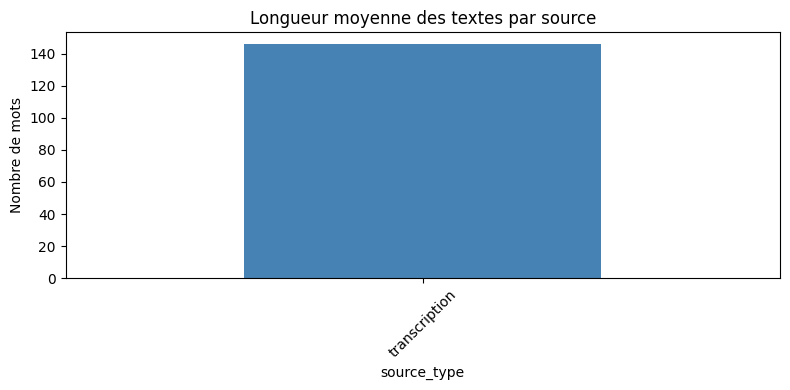

In [17]:
df_clean['nb_mots'] = df_clean['text_clean'].str.split().str.len()

longueur = df_clean.groupby('source_type')['nb_mots'].agg(['mean','min','max','median'])
longueur.columns = ['Moyenne', 'Min', 'Max', 'Médiane']
longueur = longueur.round(1)

print('Longueur des textes par source :')
print(longueur)

longueur['Moyenne'].plot(kind='bar', color='steelblue', figsize=(8,4))
plt.title('Longueur moyenne des textes par source')
plt.ylabel('Nombre de mots')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cellule 13 — Distribution arabe vs latin

Distribution arabe vs latin par catégorie :
                   pct_arabic  pct_latin
category                                
Business/Économie       100.0        0.0
Food/Cuisine            100.0        0.0
Medical/Santé           100.0        0.0
Politics/Société         99.9        0.1
Religion                100.0        0.0
Sports/Fitness          100.0        0.0


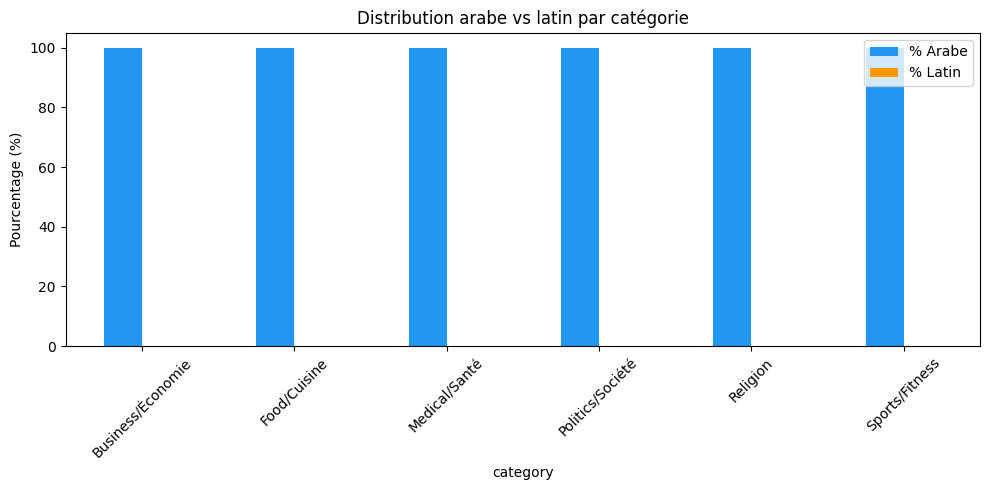

In [18]:
def detect_script(text):
    if not isinstance(text, str):
        return 0, 0
    arabic = len(re.findall(r'[\u0600-\u06FF]', text))
    latin  = len(re.findall(r'[a-zA-Z]', text))
    return arabic, latin

df_clean['arabic_chars'] = df_clean['text_clean'].apply(lambda x: detect_script(x)[0])
df_clean['latin_chars']  = df_clean['text_clean'].apply(lambda x: detect_script(x)[1])
df_clean['total_chars']  = df_clean['arabic_chars'] + df_clean['latin_chars']

df_clean['pct_arabic'] = (df_clean['arabic_chars'] / df_clean['total_chars'].replace(0,1) * 100).round(1)
df_clean['pct_latin']  = (df_clean['latin_chars']  / df_clean['total_chars'].replace(0,1) * 100).round(1)

print('Distribution arabe vs latin par catégorie :')
dist = df_clean.groupby('category')[['pct_arabic','pct_latin']].mean().round(1)
print(dist)

dist.plot(kind='bar', figsize=(10,5), color=['#2196F3','#FF9800'])
plt.title('Distribution arabe vs latin par catégorie')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(['% Arabe', '% Latin'])
plt.tight_layout()
plt.show()

## Cellule 14 — Mots fréquents

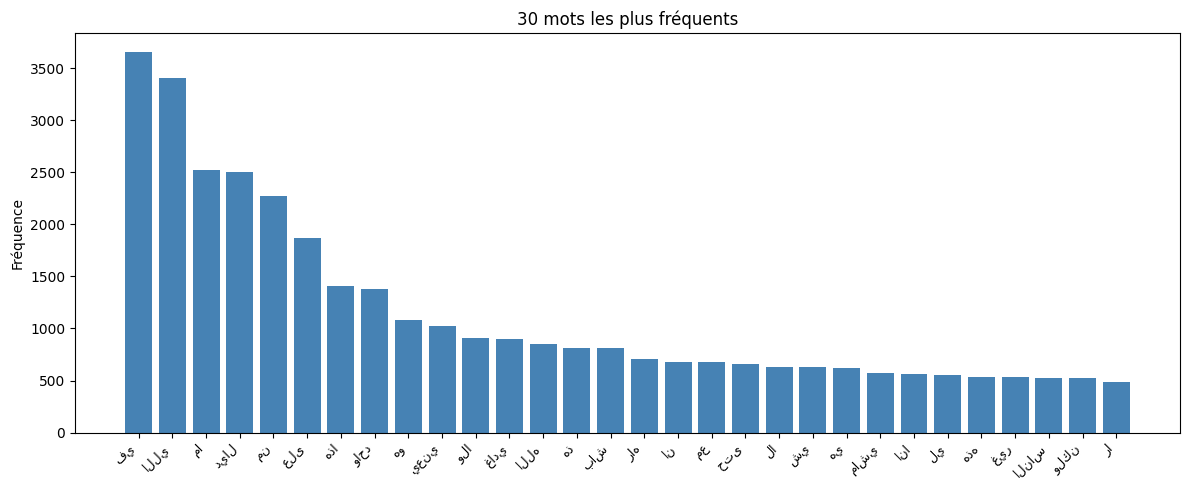


Top 30 mots :
  في                   3655
  اللي                 3402
  ما                   2523
  ديال                 2500
  من                   2269
  على                  1869
  هذا                  1412
  واحد                 1377
  هو                   1080
  يعني                 1019
  ولا                  911
  غادي                 898
  الله                 853
  هذ                   813
  باش                  813
  راه                  707
  ان                   681
  مع                   678
  حتى                  663
  لا                   629
  شي                   627
  هي                   624
  ماشي                 572
  انا                  567
  لي                   555
  هذه                  530
  غير                  529
  الناس                522
  ولكن                 520
  را                   490


In [19]:
tous_mots = ' '.join(df_clean['text_clean'].tolist()).split()
freq = Counter(tous_mots).most_common(30)

mots   = [m[0] for m in freq]
counts = [m[1] for m in freq]

plt.figure(figsize=(12,5))
plt.bar(range(len(mots)), counts, color='steelblue')
plt.xticks(range(len(mots)), mots, rotation=45, ha='right', fontsize=9)
plt.title('30 mots les plus fréquents')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

print('\nTop 30 mots :')
for mot, count in freq:
    print(f'  {mot:<20} {count}')

## Cellule 15 — Bigrammes fréquents

In [20]:
def get_bigrams(text):
    words = text.split()
    return [f'{words[i]} {words[i+1]}' for i in range(len(words)-1)]

tous_bigrams = []
for text in df_clean['text_clean']:
    tous_bigrams.extend(get_bigrams(str(text)))

freq_bigrams = Counter(tous_bigrams).most_common(20)

print('Top 20 bigrammes :')
for bigram, count in freq_bigrams:
    print(f'  {bigram:<30} {count}')

Top 20 bigrammes :
  شي حاجه                        151
  شاء الله                       146
  من بعد                         143
  ما بين                         138
  الناس اللي                     126
  ان شاء                         121
  في هذا                         117
  اللي غادي                      101
  في المغرب                      100
  ما يمكنش                       94
  هو اللي                        84
  في هذ                          81
  اللي هو                        80
  اللي هي                        79
  الى اخره                       79
  بزاف ديال                      78
  اللي كان                       78
  كيف ما                         77
  بعد ما                         75
  هذا الشي                       75


## Cellule 16 — Détection code-switching

Textes avec code-switching : 11 (1.0%)

Exemples :
['يطرا هشي حيت غدي نحصلو هنايا المهم هذ العمليه تاخذ سنوات طويله تقدر القضيه تاخذ اكثر من سبع سنين هذا القرار هو مسؤوليه وزاره الاقتصاد والماليه اذا تابع للحكومه اللي كتحكم البلاد هي اللي مسؤوله على هذا القرار ا هشي اللي كاين في هذ الحلقه بزاف الحوايج ما قلناش ولكن ماشي بالضروره نقول كلشي ال جتك الفيديو مزروب بزاف وما فهمتيش عاود الفيديو ان شاء الله غادي تفهم وصبر شويه خصكم تبارطاجيو ه الفيديو تابوناو دير جيم وقولوا السلام عليكم تهلاو n', 'تشعل الفتنه الفتنه ساهل تشعلها اللي صعيبه هي خصك هي تبردها كل واحد خص يكون صاج في هذا القدميه لا المرضى يمشيوا عند الطبيب يقولوا لي هكا لا العكس ما تمشيش تقول لي مشيت عند الطبيب كان غيقتلني اخويا واش كاين الطبيب غ يقتلك كاين شي طبيب باغي يقتل المريض ماكينش هذاشي كله باش نقول لكم را خص تكون الثقه بين المريض والطبيب اذا ماكش الثقه النص العلاج ماكينش مي كتكون الثقه النص العلاج يعني كيبقى الباروك ديال الله وشويه ديال الخدمه ويكون الخير ان شاء الله على هذ الرساله استاذ الله يرحم بها الوالدين الله يحفظك ال

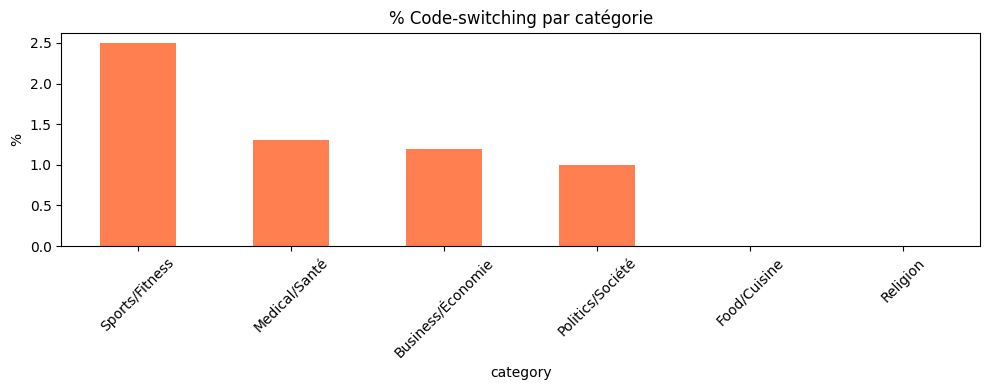

In [21]:
def detect_code_switching(text):
    if not isinstance(text, str):
        return False
    has_arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    has_latin  = bool(re.search(r'[a-zA-Z]', text))
    return has_arabic and has_latin

df_clean['code_switching'] = df_clean['text_clean'].apply(detect_code_switching)

total_cs = df_clean['code_switching'].sum()
pct_cs   = (total_cs / len(df_clean) * 100).round(1)

print(f'Textes avec code-switching : {total_cs} ({pct_cs}%)')
print(f'\nExemples :')
print(df_clean[df_clean['code_switching'] == True]['text_clean'].sample(10).tolist())

cs_cat = df_clean.groupby('category')['code_switching'].mean() * 100
cs_cat = cs_cat.round(1).sort_values(ascending=False)

print(f'\nCode-switching par catégorie :')
print(cs_cat)

cs_cat.plot(kind='bar', figsize=(10,4), color='coral')
plt.title('% Code-switching par catégorie')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cellule 17 — Sauvegarde finale

In [22]:
df_clean = df_clean.drop(columns=['text'], errors='ignore').rename(columns={'text_clean': 'text'})
df_clean.to_csv('../data/processed/all_youtube_transcriptions_clean.csv',
                index=False, encoding='utf-8-sig')

print(f'✅ Fichier sauvegardé : {len(df_clean)} textes propres')
print(f'\nRépartition finale :')
print(df_clean['category'].value_counts())

✅ Fichier sauvegardé : 1076 textes propres

Répartition finale :
category
Politics/Société     302
Religion             175
Business/Économie    166
Sports/Fitness       162
Medical/Santé        152
Food/Cuisine         119
Name: count, dtype: int64
